In [5]:
%matplotlib inline
import re
import sys
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

import psycopg2
def get_connection():
    return psycopg2.connect(
        host="localhost",
        port=os.getenv("POSTGRES_PORT", 5432),
        dbname=os.getenv("POSTGRES_DB", "newsdb"),
        user=os.getenv("POSTGRES_USER", "admin"),
        password=os.getenv("POSTGRES_PASSWORD", "supersecretpassword123"),
    )


In [6]:
conn = get_connection()
df_raw = pd.read_sql('SELECT * FROM articles ORDER BY id', conn)
print(f'Total rows: {len(df_raw):,}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head(3)

Total rows: 491
Columns: ['id', 'source', 'title', 'url', 'image', 'published_at', 'crawled_at', 'content']


,id,source,title,url,image,published_at,crawled_at,content
0,1,vnexpress,Trình duyệt Chrome ở Việt Nam được tích hợp ch...,https://vnexpress.net/trinh-duyet-chrome-o-vie...,https://i1-vnexpress.vnecdn.net/2026/04/21/gem...,2026-04-21 08:00:00+00:00,2026-04-21 10:49:03.371429+00:00,"Trong thông báo hôm 21/4, Google cho biết đã t..."
1,2,vnexpress,Cảnh 'Trái Đất lặn' quay bằng iPhone 17 Pro Max,https://vnexpress.net/canh-trai-dat-lan-quay-b...,https://i1-vnexpress.vnecdn.net/2026/04/20/rnU...,2026-04-21 02:00:00+00:00,2026-04-21 10:49:03.371429+00:00,Video quay cảnh Trái Đất lặn của Reid Wiseman....
2,3,vnexpress,"Tim Cook rời vị trí CEO Apple, chuyển giao cho...",https://vnexpress.net/tim-cook-roi-vi-tri-ceo-...,https://i1-vnexpress.vnecdn.net/2026/04/21/app...,2026-04-20 22:35:16+00:00,2026-04-21 10:49:03.371429+00:00,"Ngày 20/4, hãng cho biết quyết định đã được Hộ..."


In [7]:
df_raw.info()
print()
df_raw.isnull().sum().rename('null_count').to_frame()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   id            491 non-null    int64              
 1   source        491 non-null    object             
 2   title         491 non-null    object             
 3   url           491 non-null    object             
 4   image         205 non-null    object             
 5   published_at  491 non-null    datetime64[ns, UTC]
 6   crawled_at    491 non-null    datetime64[ns, UTC]
 7   content       480 non-null    object             
dtypes: datetime64[ns, UTC](2), int64(1), object(5)
memory usage: 30.8+ KB



,null_count
id,0
source,0
title,0
url,0
image,286
published_at,0
crawled_at,0
content,11


In [8]:
MOJIBAKE_PATTERNS = [
    ('latin1_as_utf8', r'Ã©|Ã |Ã¢|Æ°|Ã´|Ã³|Ã¹|Ã¢|Ã'),
    ('broken_sequences', r'â€™|â€œ|â€|â€˜|â€¦'),
    ('windows1252', r'â\x80\x99|â\x80\x9c|â\x80\x9d'),
]

for col in ['title', 'content']:
    for name, pattern in MOJIBAKE_PATTERNS:
        df_raw[f'{col}_{name}'] = df_raw[col].fillna('').str.contains(pattern, regex=True)

df_raw['has_mojibake'] = False
for col in ['title', 'content']:
    for name, _ in MOJIBAKE_PATTERNS:
        df_raw['has_mojibake'] |= df_raw[f'{col}_{name}']

total = len(df_raw)
moji_total = df_raw['has_mojibake'].sum()
print(f'Total articles      : {total:,}')
print(f'Has mojibake        : {moji_total:,}  ({moji_total/total*100:.1f}%)')
print(f'Clean               : {total - moji_total:,}  ({(total-moji_total)/total*100:.1f}%)')
print()
print('Mojibake breakdown by pattern:')
for col in ['title', 'content']:
    for name, _ in MOJIBAKE_PATTERNS:
        n = df_raw[f'{col}_{name}'].sum()
        print(f'  {col:10} / {name:20}: {n:,}')

Total articles      : 491
Has mojibake        : 19  (3.9%)
Clean               : 472  (96.1%)

Mojibake breakdown by pattern:
  title      / latin1_as_utf8      : 0
  title      / broken_sequences    : 0
  title      / windows1252         : 0
  content    / latin1_as_utf8      : 19
  content    / broken_sequences    : 0
  content    / windows1252         : 13


In [9]:
moji_by_source = (
    df_raw.groupby('source')
    .agg(
        total=('id', 'count'),
        mojibake=('has_mojibake', 'sum')
    )
    .assign(pct=lambda x: (x['mojibake'] / x['total'] * 100).round(1))
    .sort_values('pct', ascending=False)
)
print(moji_by_source.to_string())

              total  mojibake   pct
source                             
trainghiemso     20        19  95.0
cafebiz          61         0   0.0
dantri          100         0   0.0
thanhnien        80         0   0.0
tuoitre          50         0   0.0
vietnamnet       36         0   0.0
vnexpress       131         0   0.0
zingnews         13         0   0.0


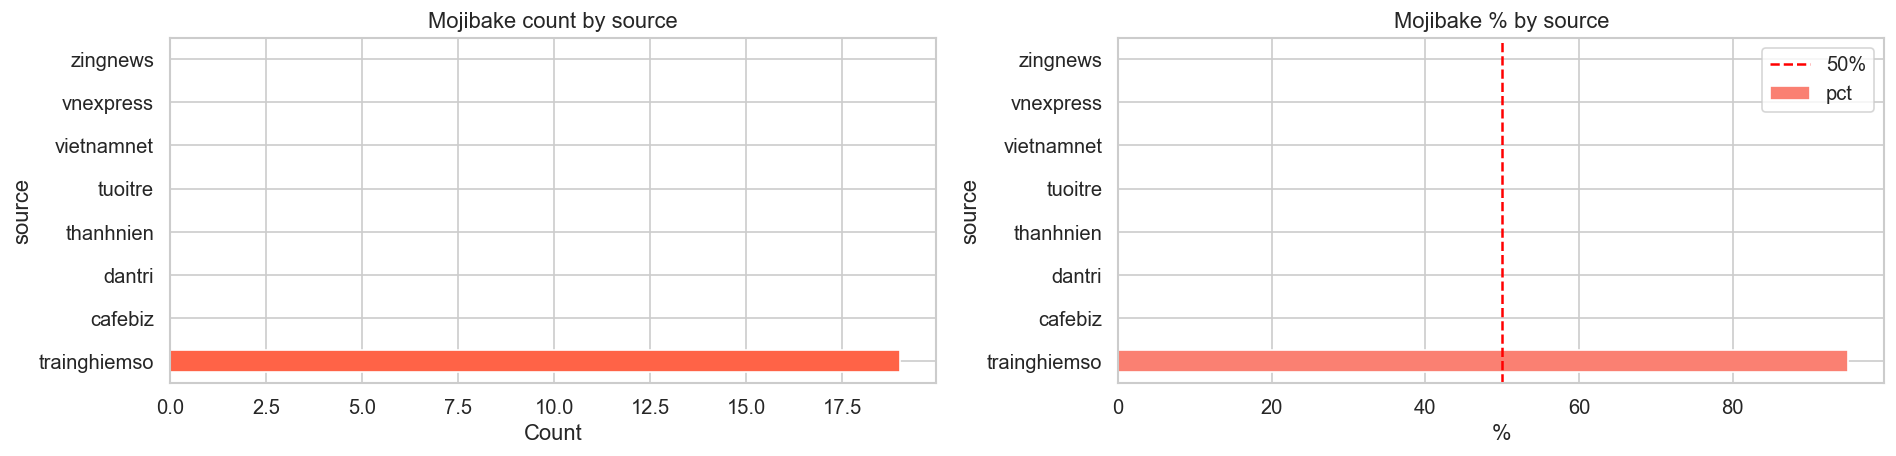

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

moji_by_source['mojibake'].plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title('Mojibake count by source')
axes[0].set_xlabel('Count')

moji_by_source['pct'].plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Mojibake % by source')
axes[1].set_xlabel('%')
axes[1].axvline(50, color='red', linestyle='--', label='50%')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
print('Sample mojibake articles:')
sample_cols = ['id', 'source', 'title', 'content']
moji_sample = df_raw[df_raw['has_mojibake']][sample_cols].head(10)
for _, row in moji_sample.iterrows():
    print(f"  [{row['source']}] id={row['id']}")
    print(f"    title  : {str(row['title'])[:120]}")
    print(f"    content: {str(row['content'])[:120]}")
    print()

Sample mojibake articles:
  [trainghiemso] id=372
    title  : Quỹ Kiến tạo Ước mơ và C06 trao tặng công trình điểm trường tại Tuyên Quang: Hơn 1,1 tỷ đồng đầu tư đồng bộ, hỗ trợ hơn 
    content: ChÆ°Æ¡ng trÃ¬nh náº±m trong káº¿ hoáº¡ch xÃ¢y dá»±ng cÃ¡c hoáº¡t Äá»ng há» trá»£ giÃ¡o dá»¥c cá»§a Quá»¹ DMF, vá»i t

  [trainghiemso] id=374
    title  : Samsung ra mắt bộ đôi TV Mini LED M8X và TV OLED S85H, chỉ mở bán tại Điện máy Xanh kèm ưu đãi hấp dẫn
    content: Samsung vÃ  Äiá»n mÃ¡y Xanh triá»n khai mÃ´ hÃ¬nh há»£p tÃ¡c nháº±m khai thÃ¡c tá»i Äa sá»©c máº¡nh cÃ´ng nghá» cá

  [trainghiemso] id=375
    title  : Dyson ra mắt máy sấy tóc Supersonic™ Travel: Nhỏ hơn 32%, nhẹ hơn 25% so với dòng tiêu chuẩn
    content: Vá»i thiáº¿t káº¿ nhá» gá»n hÆ¡n 32% vÃ  nháº¹ hÆ¡n 25% so vá»i dÃ²ng mÃ¡y sáº¥y Dyson Supersonicâ¢ tiÃªu chuáº©n, 

  [trainghiemso] id=376
    title  : LG ra mắt màn hình 6K đầu tiên hỗ trợ Thunderbolt 5 tại Việt Nam, giá từ 66,5 triệu đồng kèm ưu đãi
    

In [12]:
def try_fix_mojibake(x):
    if not isinstance(x, str):
        return x, False
    try:
        fixed = x.encode('latin1').decode('utf-8')
        return fixed, True
    except Exception:
        return x, False

moji_rows = df_raw[df_raw['has_mojibake']].copy()
moji_rows['title_fixed'], moji_rows['title_fix_ok'] = zip(*moji_rows['title'].apply(try_fix_mojibake))
moji_rows['content_fixed'], moji_rows['content_fix_ok'] = zip(*moji_rows['content'].apply(try_fix_mojibake))

fix_ok = (moji_rows['title_fix_ok'] | moji_rows['content_fix_ok']).sum()
print(f'Mojibake articles fixable via latin1->utf8: {fix_ok} / {len(moji_rows)}')
print()
print('Sample fixed:')
for _, row in moji_rows[moji_rows['title_fix_ok']].head(3).iterrows():
    print(f"  BEFORE: {str(row['title'])[:100]}")
    print(f"  AFTER : {str(row['title_fixed'])[:100]}")
    print()

Mojibake articles fixable via latin1->utf8: 5 / 19

Sample fixed:


In [13]:
df_raw['published_at'] = pd.to_datetime(df_raw['published_at'], utc=True, errors='coerce')

null_date = df_raw['published_at'].isnull().sum()
print(f'Null published_at   : {null_date:,}  ({null_date/len(df_raw)*100:.1f}%)')

now = pd.Timestamp.now(tz='UTC')
future_dates = (df_raw['published_at'] > now).sum()
very_old = (df_raw['published_at'] < pd.Timestamp('2020-01-01', tz='UTC')).sum()

print(f'Future dates        : {future_dates:,}')
print(f'Before 2020         : {very_old:,}')
print()
print('Date range by source:')
print(
    df_raw.groupby('source')['published_at']
    .agg(['min', 'max', lambda x: x.isnull().sum()])
    .rename(columns={'<lambda_0>': 'null_count'})
    .to_string()
)

Null published_at   : 0  (0.0%)
Future dates        : 6
Before 2020         : 0

Date range by source:
                                   min                       max  null_count
source                                                                      
cafebiz      2025-10-18 06:45:00+00:00 2026-03-19 06:35:00+00:00           0
dantri       2026-04-03 05:18:43+00:00 2026-04-21 02:45:53+00:00           0
thanhnien    2021-11-17 21:24:17+00:00 2026-04-21 09:00:00+00:00           0
trainghiemso 2026-04-10 15:23:34+00:00 2026-04-21 10:43:42+00:00           0
tuoitre      2026-04-02 19:46:18+00:00 2026-04-21 21:10:00+00:00           0
vietnamnet   2025-02-03 06:23:08+00:00 2025-05-06 10:11:33+00:00           0
vnexpress    2026-04-07 23:30:01+00:00 2026-04-21 08:00:00+00:00           0
zingnews     2026-04-19 22:53:11+00:00 2026-04-21 05:15:09+00:00           0


In [14]:
df_raw['content_len'] = df_raw['content'].fillna('').str.len()
df_raw['title_len'] = df_raw['title'].fillna('').str.len()

print('Content length stats:')
print(df_raw['content_len'].describe().to_string())
print()

empty_content = (df_raw['content_len'] == 0).sum()
short_content = (df_raw['content_len'] < 200).sum()
print(f'Empty content (0 chars)    : {empty_content:,}  ({empty_content/len(df_raw)*100:.1f}%)')
print(f'Short content (<200 chars) : {short_content:,}  ({short_content/len(df_raw)*100:.1f}%)')

Content length stats:
count      491.000000
mean      3027.511202
std       3906.975876
min          0.000000
25%        390.000000
50%       2729.000000
75%       4053.000000
max      68136.000000

Empty content (0 chars)    : 11  (2.2%)
Short content (<200 chars) : 91  (18.5%)


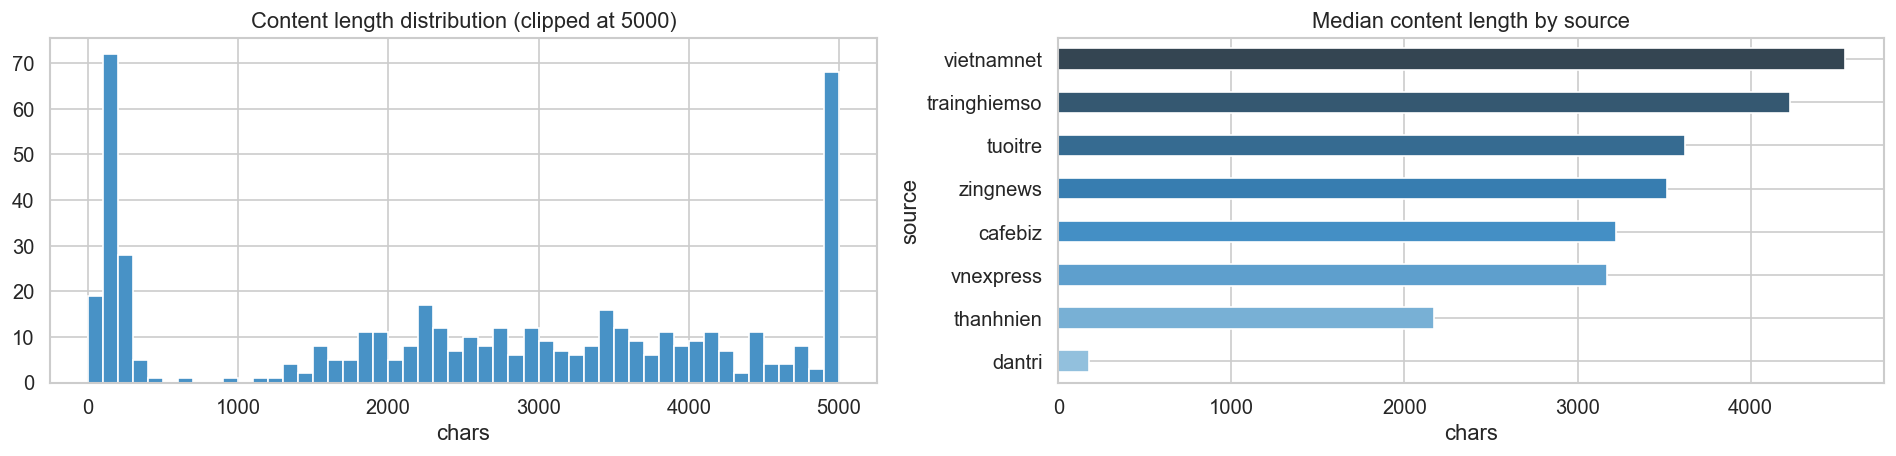

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

df_raw['content_len'].clip(upper=5000).hist(bins=50, ax=axes[0], color=sns.color_palette('Blues_d')[2])
axes[0].set_title('Content length distribution (clipped at 5000)')
axes[0].set_xlabel('chars')

df_raw.groupby('source')['content_len'].median().sort_values().plot(
    kind='barh', ax=axes[1], color=sns.color_palette('Blues_d', len(df_raw['source'].unique()))
)
axes[1].set_title('Median content length by source')
axes[1].set_xlabel('chars')

plt.tight_layout()
plt.show()

In [16]:
dup_url = df_raw.duplicated(subset=['url'], keep=False).sum()
dup_title = df_raw.duplicated(subset=['title'], keep=False).sum()
dup_content = df_raw[df_raw['content_len'] > 100].duplicated(subset=['content'], keep=False).sum()

print(f'Duplicate URLs          : {dup_url:,}')
print(f'Duplicate titles        : {dup_title:,}')
print(f'Duplicate content (>100): {dup_content:,}')
print()

if dup_url > 0:
    print('Sample duplicate URLs:')
    dup_sample = df_raw[df_raw.duplicated(subset=['url'], keep=False)].sort_values('url')
    print(dup_sample[['id', 'source', 'url']].head(6).to_string(index=False))

Duplicate URLs          : 0
Duplicate titles        : 0
Duplicate content (>100): 0



In [17]:
cutoff = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=7)
df_week = df_raw[df_raw['published_at'] >= cutoff].copy()

df_clean = df_week.drop_duplicates(subset=['url']).drop_duplicates(subset=['title']).reset_index(drop=True)

df_clean_nomoji = df_clean[~df_clean['has_mojibake']].reset_index(drop=True)
df_clean_content = df_clean_nomoji[df_clean_nomoji['content_len'] >= 200].reset_index(drop=True)

stages = {
    'raw DB': len(df_raw),
    'past 7 days': len(df_week),
    'after dedup': len(df_clean),
    'no mojibake': len(df_clean_nomoji),
    'content >= 200': len(df_clean_content),
}

print('Pipeline funnel:')
prev = None
for stage, n in stages.items():
    drop = f'  (drop {prev - n:,})' if prev is not None else ''
    print(f'  {stage:20}: {n:,}{drop}')
    prev = n

Pipeline funnel:
  raw DB              : 491
  past 7 days         : 201  (drop 290)
  after dedup         : 201  (drop 0)
  no mojibake         : 186  (drop 15)
  content >= 200      : 154  (drop 32)


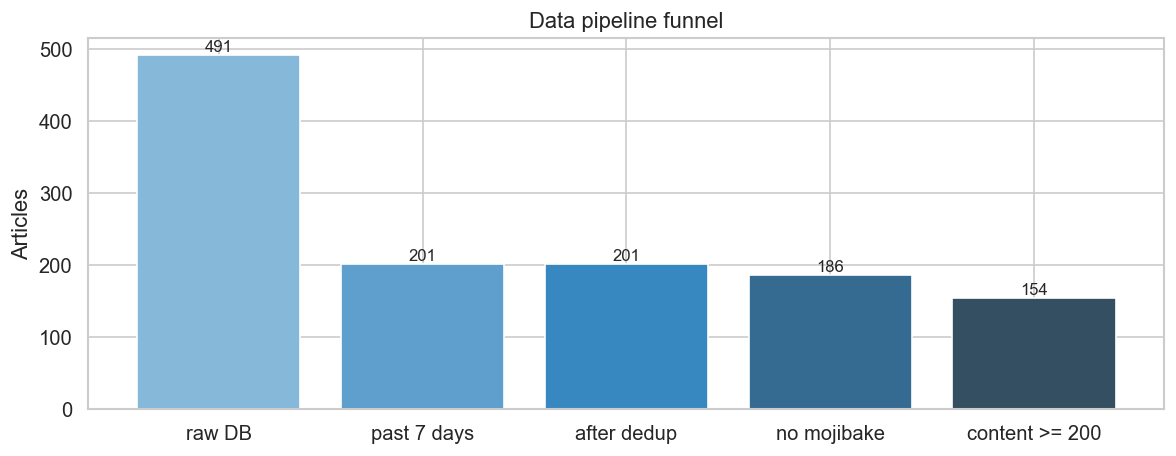

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
stage_names = list(stages.keys())
stage_vals = list(stages.values())
bars = ax.bar(stage_names, stage_vals, color=sns.color_palette('Blues_d', len(stages)))
for bar, val in zip(bars, stage_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, str(val), ha='center', va='bottom', fontsize=10)
ax.set_title('Data pipeline funnel')
ax.set_ylabel('Articles')
plt.tight_layout()
plt.show()

In [19]:
print('Per-source survival through pipeline:')
survival = (
    df_raw.groupby('source').size().rename('raw')
    .to_frame()
    .join(df_week.groupby('source').size().rename('past_7d'))
    .join(df_clean.groupby('source').size().rename('dedup'))
    .join(df_clean_nomoji.groupby('source').size().rename('no_moji'))
    .join(df_clean_content.groupby('source').size().rename('content_ok'))
    .fillna(0).astype(int)
)
survival['retention_%'] = (survival['content_ok'] / survival['raw'] * 100).round(1)
print(survival.to_string())

Per-source survival through pipeline:
              raw  past_7d  dedup  no_moji  content_ok  retention_%
source                                                             
cafebiz        61        0      0        0           0          0.0
dantri        100       38     38       38          12         12.0
thanhnien      80       33     33       33          31         38.8
trainghiemso   20       16     16        1           1          5.0
tuoitre        50       27     27       27          27         54.0
vietnamnet     36        0      0        0           0          0.0
vnexpress     131       74     74       74          70         53.4
zingnews       13       13     13       13          13        100.0


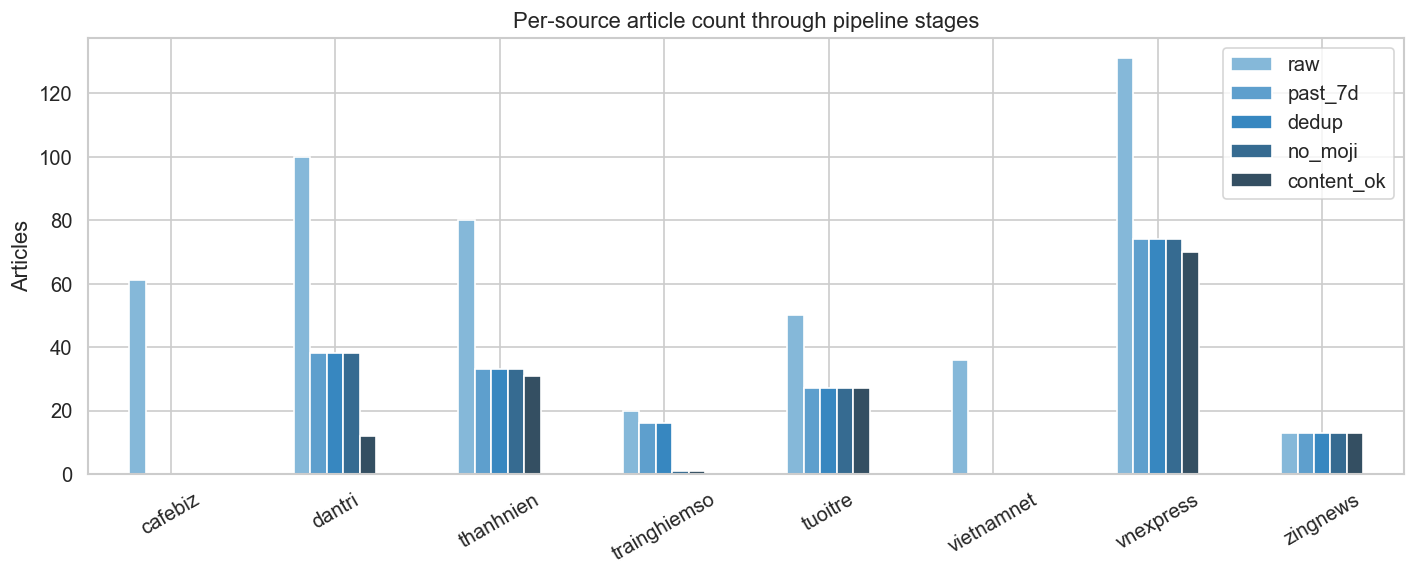

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
survival[['raw', 'past_7d', 'dedup', 'no_moji', 'content_ok']].plot(
    kind='bar', ax=ax,
    color=sns.color_palette('Blues_d', 5)
)
ax.set_title('Per-source article count through pipeline stages')
ax.set_xlabel('')
ax.set_ylabel('Articles')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()